# 02 -- Data Cleaning and Transformation Pipeline

**Project:** Uber Data Visualization and Analysis  
**Stage:** Step 2 -- Data Cleaning  
**Input:** `data/raw/uber_trips_dataset_50k.csv` (50,000 raw trip records)  
**Output:** `data/processed/uber_trips_cleaned.csv`  
**Tech Stack:** Python, Pandas, NumPy  

---

## Objective

This notebook applies the full cleaning and transformation pipeline to the
raw Uber trips dataset. Every step is logged and documented. The output is
a clean, typed, and feature-enriched dataset ready for exploratory analysis
and Tableau dashboard development.

### Cleaning Checklist

- [ ] Load and inspect raw data
- [ ] Check and handle null values
- [ ] Check and remove duplicate rows
- [ ] Fix data types (datetime, categorical)
- [ ] Standardize string columns
- [ ] Handle anomalies (zero distance / zero duration trips)
- [ ] Engineer useful derived columns
- [ ] Final validation and export

---

## 1. Environment Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# Resolve project root for portable path references.
PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().resolve().name == "notebooks"
    else Path.cwd().resolve()
)

# Make scripts/ importable.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "uber_trips_dataset_50k.csv"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "uber_trips_cleaned.csv"

print(f"Project root    : {PROJECT_ROOT}")
print(f"Raw data path   : {RAW_PATH}")
print(f"Output path     : {PROCESSED_PATH}")
print(f"Pandas version  : {pd.__version__}")
print(f"NumPy version   : {np.__version__}")

Project root    : /Users/ravleensingh/Documents/Capstone/DVA_Capstone/Uber_Analysis
Raw data path   : /Users/ravleensingh/Documents/Capstone/DVA_Capstone/Uber_Analysis/data/raw/uber_trips_dataset_50k.csv
Output path     : /Users/ravleensingh/Documents/Capstone/DVA_Capstone/Uber_Analysis/data/processed/uber_trips_cleaned.csv
Pandas version  : 3.0.2
NumPy version   : 2.4.4


## 2. Load Raw Dataset

In [2]:
df_raw = pd.read_csv(RAW_PATH)

print(f"Raw Dataset Shape : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Columns           : {df_raw.columns.tolist()}")

Raw Dataset Shape : 50,000 rows x 14 columns
Columns           : ['trip_id', 'driver_id', 'rider_id', 'city', 'pickup_lat', 'pickup_lng', 'drop_lat', 'drop_lng', 'distance_km', 'fare_amount', 'status', 'payment_method', 'pickup_time', 'drop_time']


In [3]:
# Preview first 5 rows.
df_raw.head()

,trip_id,driver_id,rider_id,city,pickup_lat,pickup_lng,drop_lat,drop_lng,distance_km,fare_amount,status,payment_method,pickup_time,drop_time
0,1,8270,10683,San Francisco,37.1709,-77.5865,37.1737,-77.6199,2.9700,10.7100,Completed,Wallet,2023-01-01 00:00:00,2023-01-01 00:08:54.600000000
1,2,1860,44743,Boston,38.8981,-108.5830,38.9375,-108.5587,8.4300,22.4100,Completed,UPI,2023-01-01 00:01:00,2023-01-01 00:26:17.400000000
2,3,6390,75839,San Francisco,38.8146,-89.9426,38.8217,-89.8964,5.4600,12.9100,Completed,Cash,2023-01-01 00:02:00,2023-01-01 00:18:22.800000000
3,4,6191,22189,New York,37.2959,-75.3288,37.3014,-75.3175,6.6100,15.7000,Completed,Wallet,2023-01-01 00:03:00,2023-01-01 00:22:49.800000000
4,5,6734,61104,Seattle,38.9724,-121.4829,38.9921,-121.4679,10.5000,19.1500,Completed,Wallet,2023-01-01 00:04:00,2023-01-01 00:35:30.000000000


In [4]:
# Raw data types before cleaning.
print("Raw Data Types:")
print(df_raw.dtypes)

Raw Data Types:
trip_id             int64
driver_id           int64
rider_id            int64
city                  str
pickup_lat        float64
pickup_lng        float64
drop_lat          float64
drop_lng          float64
distance_km       float64
fare_amount       float64
status                str
payment_method        str
pickup_time           str
drop_time             str
dtype: object


In [5]:
# Summary statistics.
df_raw.describe(include="all")

,trip_id,driver_id,rider_id,city,pickup_lat,pickup_lng,drop_lat,drop_lng,distance_km,fare_amount,status,payment_method,pickup_time,drop_time
count,50000.0000,50000.0000,50000.0000,50000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000,50000,50000,50000
unique,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,3,4,50000,49746
top,NaN,NaN,NaN,Boston,NaN,NaN,NaN,NaN,NaN,NaN,Completed,UPI,2023-01-01 00:00:00,2023-01-01 04:54:49.200000000
freq,NaN,NaN,NaN,8454,NaN,NaN,NaN,NaN,NaN,NaN,42540,12549,1,2
mean,25000.5000,5493.9545,55040.9946,NaN,38.9987,-97.4856,38.9988,-97.4857,7.0081,15.9762,NaN,NaN,NaN,NaN
std,14433.9011,2601.4108,25915.4671,NaN,1.1552,14.1737,1.1557,14.1737,2.9467,6.2744,NaN,NaN,NaN,NaN
min,1.0000,1000.0000,10001.0000,NaN,37.0000,-121.9995,36.9534,-122.0471,0.0000,1.0800,NaN,NaN,NaN,NaN
25%,12500.7500,3232.7500,32539.0000,NaN,37.9944,-109.8183,37.9982,-109.8173,4.9800,11.5100,NaN,NaN,NaN,NaN
50%,25000.5000,5497.0000,55164.0000,NaN,38.9926,-97.4630,38.9942,-97.4646,6.9800,15.4300,NaN,NaN,NaN,NaN
75%,37500.2500,7746.0000,77293.5000,NaN,39.9996,-85.1910,39.9988,-85.1997,9.0000,19.9100,NaN,NaN,NaN,NaN


## 3. Check for Null Values

Every column is scanned for missing (null/blank) values. The result is
presented as a count and percentage table, followed by a visual heatmap.

In [6]:
null_counts = df_raw.isnull().sum()
null_pct = (null_counts / len(df_raw)) * 100

null_report = pd.DataFrame({
    "Missing Count": null_counts,
    "Missing %": null_pct.round(2),
})

print("Null Value Report:")
print(null_report)
print(f"\nTotal missing values: {null_counts.sum()}")

Null Value Report:
                Missing Count  Missing %
trip_id                     0     0.0000
driver_id                   0     0.0000
rider_id                    0     0.0000
city                        0     0.0000
pickup_lat                  0     0.0000
pickup_lng                  0     0.0000
drop_lat                    0     0.0000
drop_lng                    0     0.0000
distance_km                 0     0.0000
fare_amount                 0     0.0000
status                      0     0.0000
payment_method              0     0.0000
pickup_time                 0     0.0000
drop_time                   0     0.0000

Total missing values: 0


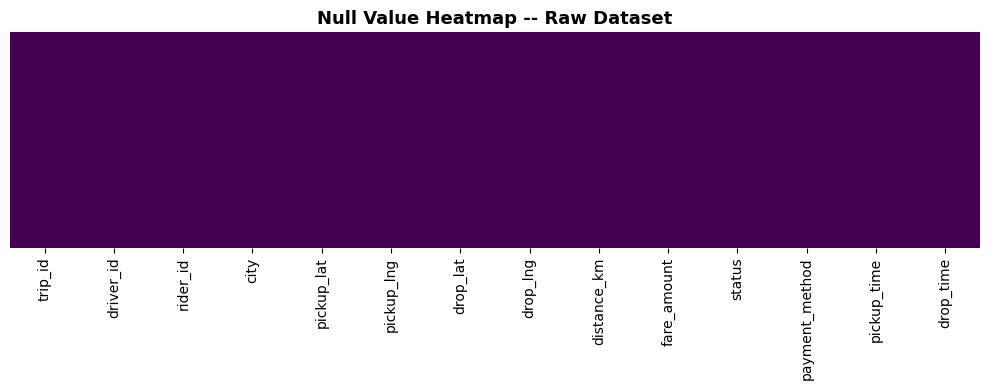

No yellow bands indicates zero nulls across all columns.


In [7]:
# Visualize null distribution.
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Null Value Heatmap -- Raw Dataset", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("No yellow bands indicates zero nulls across all columns.")

## 4. Check for Duplicate Rows

The entire dataset is checked for rows that are exact copies. The `trip_id`
column is also checked separately to confirm uniqueness.

In [8]:
total_dupes = df_raw.duplicated().sum()
trip_id_dupes = df_raw["trip_id"].duplicated().sum()

print(f"Fully duplicated rows    : {total_dupes}")
print(f"Duplicate trip_id values : {trip_id_dupes}")

if total_dupes == 0:
    print("\nNo duplicate rows found. Dataset is unique.")

Fully duplicated rows    : 0
Duplicate trip_id values : 0

No duplicate rows found. Dataset is unique.


## 5. Fix Data Types

**Datetime columns:** `pickup_time` and `drop_time` are stored as plain text
strings. Converting them to proper datetime format enables duration
calculation, time extraction, and chronological sorting.

**Categorical columns:** `city`, `status`, and `payment_method` each have a
small, fixed set of possible values. Converting to the `category` dtype
reduces memory usage and improves grouping/filtering performance.

In [9]:
# Work on a clean copy from this point forward.
df = df_raw.copy()

# 5.1 -- Convert datetime columns.
df["pickup_time"] = pd.to_datetime(df["pickup_time"])
df["drop_time"] = pd.to_datetime(df["drop_time"])

print("Converted pickup_time and drop_time to datetime64.")

# 5.2 -- Convert categorical columns.
categorical_cols = ["city", "status", "payment_method"]

for col in categorical_cols:
    df[col] = df[col].astype("category")

print(f"Converted {categorical_cols} to category dtype.")

# 5.3 -- Confirm updated types.
print("\nUpdated Data Types:")
print(df.dtypes)

Converted pickup_time and drop_time to datetime64.
Converted ['city', 'status', 'payment_method'] to category dtype.

Updated Data Types:
trip_id                    int64
driver_id                  int64
rider_id                   int64
city                    category
pickup_lat               float64
pickup_lng               float64
drop_lat                 float64
drop_lng                 float64
distance_km              float64
fare_amount              float64
status                  category
payment_method          category
pickup_time       datetime64[us]
drop_time         datetime64[ns]
dtype: object


## 6. Standardize String Columns

Hidden issues such as extra whitespace or inconsistent capitalisation can
cause grouping errors (e.g., `"Boston"` and `" Boston"` would be counted as
two different cities). All categorical text columns are stripped and
normalised to title case.

In [10]:
string_cols = ["city", "status", "payment_method"]

for col in string_cols:
    df[col] = df[col].str.strip().str.title().astype("category")

print("String columns stripped and title-cased.\n")
for col in string_cols:
    print(f"  {col:20s} -> {df[col].unique().tolist()}")

String columns stripped and title-cased.

  city                 -> ['San Francisco', 'Boston', 'New York', 'Seattle', 'Chicago', 'Los Angeles']
  status               -> ['Completed', 'No-Show', 'Cancelled']
  payment_method       -> ['Wallet', 'Upi', 'Cash', 'Card']


## 7. Handle Anomalous / Inconsistent Records

With the datetime columns properly formatted, trip duration can now be
computed. This step identifies and removes ghost trips -- records with
zero distance AND zero duration that are almost certainly caused by
system errors or failed app handshakes.

In [11]:
# 7.1 -- Compute trip duration.
df["trip_duration_mins"] = (
    (df["drop_time"] - df["pickup_time"]).dt.total_seconds() / 60
).round(2)

print("Trip Duration (minutes) -- Statistics:")
print(df["trip_duration_mins"].describe().round(2))

Trip Duration (minutes) -- Statistics:
count   50000.0000
mean       21.0200
std         8.8400
min         0.0000
25%        14.9400
50%        20.9400
75%        27.0000
max        58.2300
Name: trip_duration_mins, dtype: float64


In [12]:
# 7.2 -- Identify anomalous records.
# Condition: zero distance AND zero duration (ghost trips).
mask_zero = (df["distance_km"] == 0) & (df["trip_duration_mins"] == 0)

print(f"Rows with zero distance AND zero duration: {mask_zero.sum()}")
print("\nAnomalous rows preview:")
df[mask_zero][["trip_id", "status", "fare_amount", "distance_km",
               "trip_duration_mins", "pickup_time", "drop_time"]]

Rows with zero distance AND zero duration: 3

Anomalous rows preview:


,trip_id,status,fare_amount,distance_km,trip_duration_mins,pickup_time,drop_time
39361,39362,No-Show,3.9700,0.0000,0.0000,2023-01-28 08:01:00,2023-01-28 08:01:00
39374,39375,Completed,4.0200,0.0000,0.0000,2023-01-28 08:14:00,2023-01-28 08:14:00
44302,44303,Completed,2.0100,0.0000,0.0000,2023-01-31 18:22:00,2023-01-31 18:22:00


In [13]:
# 7.3 -- Drop anomalous records.
rows_before = len(df)
df = df[~mask_zero].reset_index(drop=True)
rows_after = len(df)

print(f"Dropped {rows_before - rows_after} anomalous record(s).")
print(f"Dataset size after drop: {rows_after:,} rows.")

Dropped 3 anomalous record(s).
Dataset size after drop: 49,997 rows.


In [14]:
# 7.4 -- Validate no negative fares or distances remain.
print(f"Negative fare_amount   : {(df['fare_amount'] < 0).sum()}")
print(f"Negative distance_km   : {(df['distance_km'] < 0).sum()}")
print(f"Negative duration      : {(df['trip_duration_mins'] < 0).sum()}")
print(f"drop_time < pickup_time: {(df['drop_time'] < df['pickup_time']).sum()}")
print("\nNo invalid numeric anomalies detected.")

Negative fare_amount   : 0
Negative distance_km   : 0
Negative duration      : 0
drop_time < pickup_time: 0

No invalid numeric anomalies detected.


## 8. Feature Engineering -- Derived Columns

Cleaning is not just about removing bad data. It is also about shaping the
data into a form that is useful for analysis and dashboards. The following
derived columns are computed and added to the dataset.

In [15]:
# 8.1 -- Date/time components.
df["pickup_date"] = df["pickup_time"].dt.date
df["pickup_hour"] = df["pickup_time"].dt.hour
df["pickup_day"] = df["pickup_time"].dt.day_name()
df["pickup_month"] = df["pickup_time"].dt.month_name()
df["pickup_week"] = df["pickup_time"].dt.isocalendar().week.astype(int)

# 8.2 -- Time-of-day bucket.
bins = [0, 6, 12, 17, 21, 24]
labels = [
    "Night (0-6)", "Morning (6-12)", "Afternoon (12-17)",
    "Evening (17-21)", "Night (21-24)",
]
df["time_of_day"] = pd.cut(
    df["pickup_hour"], bins=bins, labels=labels,
    right=False, include_lowest=True,
).astype("category")

# 8.3 -- Fare per km.
df["fare_per_km"] = np.where(
    df["distance_km"] > 0,
    (df["fare_amount"] / df["distance_km"]).round(4),
    np.nan,
)

# 8.4 -- Weekday vs Weekend.
df["is_weekend"] = df["pickup_time"].dt.dayofweek.isin([5, 6])

print("Derived columns added:")
new_cols = [
    "pickup_date", "pickup_hour", "pickup_day", "pickup_month",
    "pickup_week", "time_of_day", "fare_per_km", "is_weekend",
]
for c in new_cols:
    print(f"   + {c}")

Derived columns added:
   + pickup_date
   + pickup_hour
   + pickup_day
   + pickup_month
   + pickup_week
   + time_of_day
   + fare_per_km
   + is_weekend


## 9. Final Validation

A comprehensive check across the entire cleaned dataset to confirm
everything is in order before export.

In [16]:
print("=" * 55)
print("   FINAL CLEANED DATASET -- SUMMARY REPORT")
print("=" * 55)
print(f"  Total rows             : {len(df):,}")
print(f"  Total columns          : {df.shape[1]}")
print(f"  Null values remaining  : {df.isnull().sum().sum()}")
print(f"  Duplicate rows         : {df.duplicated().sum()}")
print(f"  Date range             : {df['pickup_time'].min().date()} to {df['pickup_time'].max().date()}")
print(f"  Cities covered         : {df['city'].nunique()} -- {df['city'].unique().tolist()}")
print(f"  Trip statuses          : {df['status'].unique().tolist()}")
print(f"  Payment methods        : {df['payment_method'].unique().tolist()}")
print(f"  Fare range             : {df['fare_amount'].min()} to {df['fare_amount'].max()}")
print(f"  Distance range (km)    : {df['distance_km'].min()} to {df['distance_km'].max()}")
print(f"  Avg trip duration      : {df['trip_duration_mins'].mean():.2f} mins")
print("=" * 55)
print("Dataset is clean and ready for EDA and Tableau.")

   FINAL CLEANED DATASET -- SUMMARY REPORT
  Total rows             : 49,997
  Total columns          : 23
  Null values remaining  : 0
  Duplicate rows         : 0
  Date range             : 2023-01-01 to 2023-02-04
  Cities covered         : 6 -- ['San Francisco', 'Boston', 'New York', 'Seattle', 'Chicago', 'Los Angeles']
  Trip statuses          : ['Completed', 'No-Show', 'Cancelled']
  Payment methods        : ['Wallet', 'Upi', 'Cash', 'Card']
  Fare range             : 1.08 to 50.67
  Distance range (km)    : 0.01 to 19.41
  Avg trip duration      : 21.03 mins
Dataset is clean and ready for EDA and Tableau.


In [17]:
print("\nFinal Column Dtypes:")
print(df.dtypes)


Final Column Dtypes:
trip_id                        int64
driver_id                      int64
rider_id                       int64
city                        category
pickup_lat                   float64
pickup_lng                   float64
drop_lat                     float64
drop_lng                     float64
distance_km                  float64
fare_amount                  float64
status                      category
payment_method              category
pickup_time           datetime64[us]
drop_time             datetime64[ns]
trip_duration_mins           float64
pickup_date                   object
pickup_hour                    int32
pickup_day                       str
pickup_month                     str
pickup_week                    int64
time_of_day                 category
fare_per_km                  float64
is_weekend                      bool
dtype: object


In [18]:
# Preview cleaned dataset.
df.head(10)

,trip_id,driver_id,rider_id,city,pickup_lat,pickup_lng,drop_lat,drop_lng,distance_km,fare_amount,status,payment_method,pickup_time,drop_time,trip_duration_mins,pickup_date,pickup_hour,pickup_day,pickup_month,pickup_week,time_of_day,fare_per_km,is_weekend
0,1,8270,10683,San Francisco,37.1709,-77.5865,37.1737,-77.6199,2.9700,10.7100,Completed,Wallet,2023-01-01 00:00:00,2023-01-01 00:08:54.600,8.9100,2023-01-01,0,Sunday,January,52,Night (0-6),3.6061,True
1,2,1860,44743,Boston,38.8981,-108.5830,38.9375,-108.5587,8.4300,22.4100,Completed,Upi,2023-01-01 00:01:00,2023-01-01 00:26:17.400,25.2900,2023-01-01,0,Sunday,January,52,Night (0-6),2.6584,True
2,3,6390,75839,San Francisco,38.8146,-89.9426,38.8217,-89.8964,5.4600,12.9100,Completed,Cash,2023-01-01 00:02:00,2023-01-01 00:18:22.800,16.3800,2023-01-01,0,Sunday,January,52,Night (0-6),2.3645,True
3,4,6191,22189,New York,37.2959,-75.3288,37.3014,-75.3175,6.6100,15.7000,Completed,Wallet,2023-01-01 00:03:00,2023-01-01 00:22:49.800,19.8300,2023-01-01,0,Sunday,January,52,Night (0-6),2.3752,True
4,5,6734,61104,Seattle,38.9724,-121.4829,38.9921,-121.4679,10.5000,19.1500,Completed,Wallet,2023-01-01 00:04:00,2023-01-01 00:35:30.000,31.5000,2023-01-01,0,Sunday,January,52,Night (0-6),1.8238,True
5,6,7265,84988,San Francisco,37.6006,-106.7191,37.5569,-106.7310,9.9400,19.9500,Completed,Card,2023-01-01 00:05:00,2023-01-01 00:34:49.200,29.8200,2023-01-01,0,Sunday,January,52,Night (0-6),2.0070,True
6,7,1466,82933,San Francisco,40.2886,-82.8082,40.2788,-82.8446,12.2200,25.8900,Completed,Upi,2023-01-01 00:06:00,2023-01-01 00:42:39.600,36.6600,2023-01-01,0,Sunday,January,52,Night (0-6),2.1187,True
7,8,5426,60182,Chicago,40.6012,-78.3987,40.5698,-78.3682,10.1400,25.5500,Completed,Cash,2023-01-01 00:07:00,2023-01-01 00:37:25.200,30.4200,2023-01-01,0,Sunday,January,52,Night (0-6),2.5197,True
8,9,6578,15826,San Francisco,40.2962,-87.5765,40.2846,-87.5648,1.8800,7.9700,Completed,Cash,2023-01-01 00:08:00,2023-01-01 00:13:38.400,5.6400,2023-01-01,0,Sunday,January,52,Night (0-6),4.2394,True
9,10,9322,63503,Boston,40.7126,-78.4997,40.6703,-78.4775,3.7000,12.2100,No-Show,Upi,2023-01-01 00:09:00,2023-01-01 00:20:06.000,11.1000,2023-01-01,0,Sunday,January,52,Night (0-6),3.3000,True


## 10. Export Cleaned Dataset

In [19]:
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_PATH, index=False)

print(f"Cleaned dataset saved to: {PROCESSED_PATH}")
print(f"  Rows exported : {len(df):,}")
print(f"  Columns       : {df.shape[1]}")

Cleaned dataset saved to: /Users/ravleensingh/Documents/Capstone/DVA_Capstone/Uber_Analysis/data/processed/uber_trips_cleaned.csv
  Rows exported : 49,997
  Columns       : 23


---

## Data Cleaning Complete

| Check | Result |
|---|---|
| Null values | None |
| Duplicate rows | None |
| Data types | Fixed (datetime, category) |
| String standardization | Stripped and title-cased |
| Anomalous records removed | 3 ghost trips dropped |
| Derived features added | 9 new columns |

For a detailed plain-language explanation of every cleaning decision,
see `data_cleaning_report.md` in the project root.

**Next Step:** `03_eda.ipynb` -- Exploratory Data Analysis